# Práctica Machine Learning Final: Predicción del mercado de valores

## Qué hacer:
1. **Análisis Exploratorio de Datos (EDA)**:
   - Cargar y explorar el conjunto de datos.
   - Preprocesar los datos: limpieza, manejo de valores faltantes y transformación de características.

2. **Selección y Entrenamiento de Modelos**:
   - Probar varios algoritmos de Machine Learning (LGBMRegressor y otro que hayas visto en clase).

3. **Validación del rendimiento**:
   - Utilizar técnicas de validación cruzada para evaluar el rendimiento de los modelos.

4. **Mejora (Opcional)**:
   - Investigar sobre Feature Neutralization y aplicarla para mejorar el rendimiento del modelo.
   - Ridge Regression como modelo adicional.

5. **Evaluar con live.parquet**:
   - Utilizar el archivo `live.parquet` para evaluar el rendimiento del modelo en datos no vistos.

In [60]:
# Instala dependencias
!pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1
!pip install -q --no-deps numerai-tools

# Gráficas Inline
%matplotlib inline


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
# Importa librerías
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report
from sklearn.preprocessing import Binarizer
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from numerapi import NumerAPI
from sklearn.svm import SVC
from scipy import stats
import lightgbm as lgb
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import json

In [62]:
# Funciones auxiliares

# La principal métrica de scoring:
def practica_corr(preds, target):
    # clasifica (manteniendo vínculos) y luego gaussianiza las predicciones para estandarizar las distribuciones de predicción
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    # centra objetivos alrededor de 0
    centered_target = target - target.mean()
    # Levanta ambas predicciones y apunta a la potencia de 1,5 para acentuar las colas.
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    # Finalmente devuelve el Pearson correlation
    return np.corrcoef(preds_p15, target_p15)[0, 1]

# Calcula métricas relevantes para el modelo
def compute_metrics(per_era_corr, model_name):
    corr_mean = per_era_corr.mean()
    corr_std = per_era_corr.std(ddof=0)
    corr_sharpe = corr_mean / corr_std
    max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()
    
    return pd.DataFrame({
        "mean": corr_mean,
        "std": corr_std,
        "sharpe": corr_sharpe,
        "max_drawdown": max_drawdown
    }, index=[model_name])

## 1. Análisis Exploratorio de Datos (EDA)

In [63]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

Tenemos cuatro archivos principales:
- `train.parquet`: Datos históricos con valores objetivo.
- `features.json`: Descripción de las características disponibles.
- `validation.parquet`: Datos históricos para validar el modelo.
- `live.parquet`: Datos en tiempo real para evaluar el modelo.

El primero de ellos se dividirá en conjunto de entrenamiento y validación.


#### Descargamos datos de train y de test, con el tamaño 'small' de las features_set

In [64]:
# Descarga los datos de entrenamiento, validación y las características disponibles.

napi.download_dataset(f"{DATA_VERSION}/train.parquet");
napi.download_dataset(f"{DATA_VERSION}/features.json");
napi.download_dataset(f"{DATA_VERSION}/validation.parquet");

2025-11-04 13:49:39,779 INFO numerapi.utils: target file already exists
2025-11-04 13:49:39,780 INFO numerapi.utils: download complete
2025-11-04 13:49:41,014 INFO numerapi.utils: target file already exists
2025-11-04 13:49:41,015 INFO numerapi.utils: download complete
2025-11-04 13:49:42,206 INFO numerapi.utils: target file already exists
2025-11-04 13:49:42,207 INFO numerapi.utils: download complete


In [65]:
# Carga los datos de entrenamiento.
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set])) # Tenemos la posibilidad de usar tres conjuntos de características diferentes.

feature_set = feature_sets["small"] # Vamos a utilizar el small para que tanto el entrenamiento como las graficas sean más rápidas.
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# Reduce la muestra, tomando cada cuatro eras, para reducir el uso de memoria y acelerar el entrenamiento del modelo (toma las eras 0001, 0005, 0009, ...)
train = train[train["era"].isin(train["era"].unique()[::4])]


# Carga de los datos de validación.
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Las eras están separadas por una semana, pero los "targets" miran 4 semanas en el futuro, por lo que debemos "embargar" las 4 eras posteriores a nuestra última "era" para evitar fuga de datos.
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]


small 42
medium 705
all 2376


In [66]:
train.head()

,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.250000,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.250000,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.750000,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.250000,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.250000,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2


In [67]:
validation.head()

,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0003806f5bad605,0577,0.500000,0,0,1,0,3,1,0,4,...,1,1,1,0,1,4,3,2,0,0
n000be59a0bee991,0577,0.750000,2,4,3,3,2,0,2,2,...,0,3,2,2,4,2,3,3,0,4
n00140a076404e34,0577,0.500000,4,0,1,1,1,1,3,3,...,0,1,1,1,1,0,4,0,3,4
n0026f6c0fbc483a,0577,0.250000,1,0,0,1,0,3,0,2,...,2,3,2,0,3,1,1,2,3,3
n002b74421382a36,0577,0.250000,4,1,3,2,1,0,3,3,...,3,3,1,1,1,3,4,2,4,3


### Visualizamos datos nulos y tipos de datos

In [68]:
print(f"Train shape: {train.shape}")
print(f"Validation shape: {validation.shape}")
print(f"Tipo de datos de las features, era y target: \nfeatures   {train[feature_set].dtypes.unique() } \n{train[['era', 'target']].dtypes}")
print(f"Cantidad de nulos en train: {train.isnull().sum().sum()}")
print(f"Cantidad de nulos en validation: {validation.isnull().sum().sum()}")

Train shape: (688184, 44)
Validation shape: (3782241, 44)
Tipo de datos de las features, era y target: 
features   [dtype('int8')] 
era        object
target    float32
dtype: object
Cantidad de nulos en train: 0
Cantidad de nulos en validation: 0


No hay valores nulos en el dataset de entrenamiento. Todos los datos son de tipo float32, excepto las columnas `era` y `id`.

### Gráficas

#### Figura 1: Número de filas por era y distribución de la última feature

1. **Número de filas por era**  
   - Se muestra la cantidad de observaciones por cada era del dataset.  
   - Permite identificar desequilibrios o cambios en la cantidad de datos por periodo temporal.

2. **Histograma de la primera era**  
   - Distribución de la última feature seleccionada (`feature_set[-1]`) en la primera era.  
   - Ayuda a visualizar que si faltaban datos de una era en particular, se le rellenaba con el valor 2.

3. **Histograma de la última era**  
   - Distribución de la misma feature en la última era. Viendo que aquí ya se disponía de más datos.

#### Figura 2: Distribución de features, correlación y heatmap

1. **Distribución de 10 features aleatorias**  
   - Boxplot de 10 features seleccionadas al azar del dataset.  
   - Cada caja representa la mediana, los cuartiles y posibles outliers de cada feature.  
   - Permite comparar rápidamente el rango y la variabilidad de diferentes features.

2. **Correlación con target**  
   - Barras horizontales mostrando la correlación de cada feature con el target.  
   - Identifica qué features tienen mayor relación lineal con la variable objetivo.

3. **Heatmap de correlación de un subset de features**  
   - Muestra la matriz de correlación de las primeras 20 features.  
   - Útil para detectar multicolinealidad y relaciones entre features.


#### Figura 3: Histograma del target y histogramas de features seleccionadas

1. **Histograma del target**  
   - Distribución de la variable objetivo (`target`).  
   - Permite identificar sesgo, simetría y posibles outliers en la variable a predecir.

2. **Histogramas de features seleccionadas**  
   - Distribución de algunas features específicas del dataset (limitadas a 2 para visualización clara).  
   - Ayuda a entender la forma y dispersión de los datos de entrada.


#### Figura 4: Correlaciones por era
- Suma acumulada de las correlaciones de cada feature con el target a lo largo de las eras.
- Permite observar cómo varían las correlaciones a lo largo del tiempo y detectar posibles drifts.

#### Observaciones generales

- Estas visualizaciones permiten **explorar la distribución de los datos**, detectar posibles **drifts temporales** y **relaciones lineales** con el target.  
- Los boxplots y histogramas son útiles para detectar **outliers y sesgos**, mientras que las correlaciones y scatter matrix ayudan a **identificar features relevantes y redundantes**.  
- Podemos ver que entre las features no hay una correlación muy alta, lo cual es bueno para evitar multicolinealidad.
- Vemos que hay algunas features con mayor correlación con el target que otras, lo cual puede ser útil para la selección de características.
- Vemos que no hay outliners en las features, ya que está muy estandarizado con el objetivo de evitar el overfitting
- Vemos que las correlaciones de las features con el target varían a lo largo de las eras, lo cual puede indicar cambios en el mercado o en la relevancia de ciertas características.


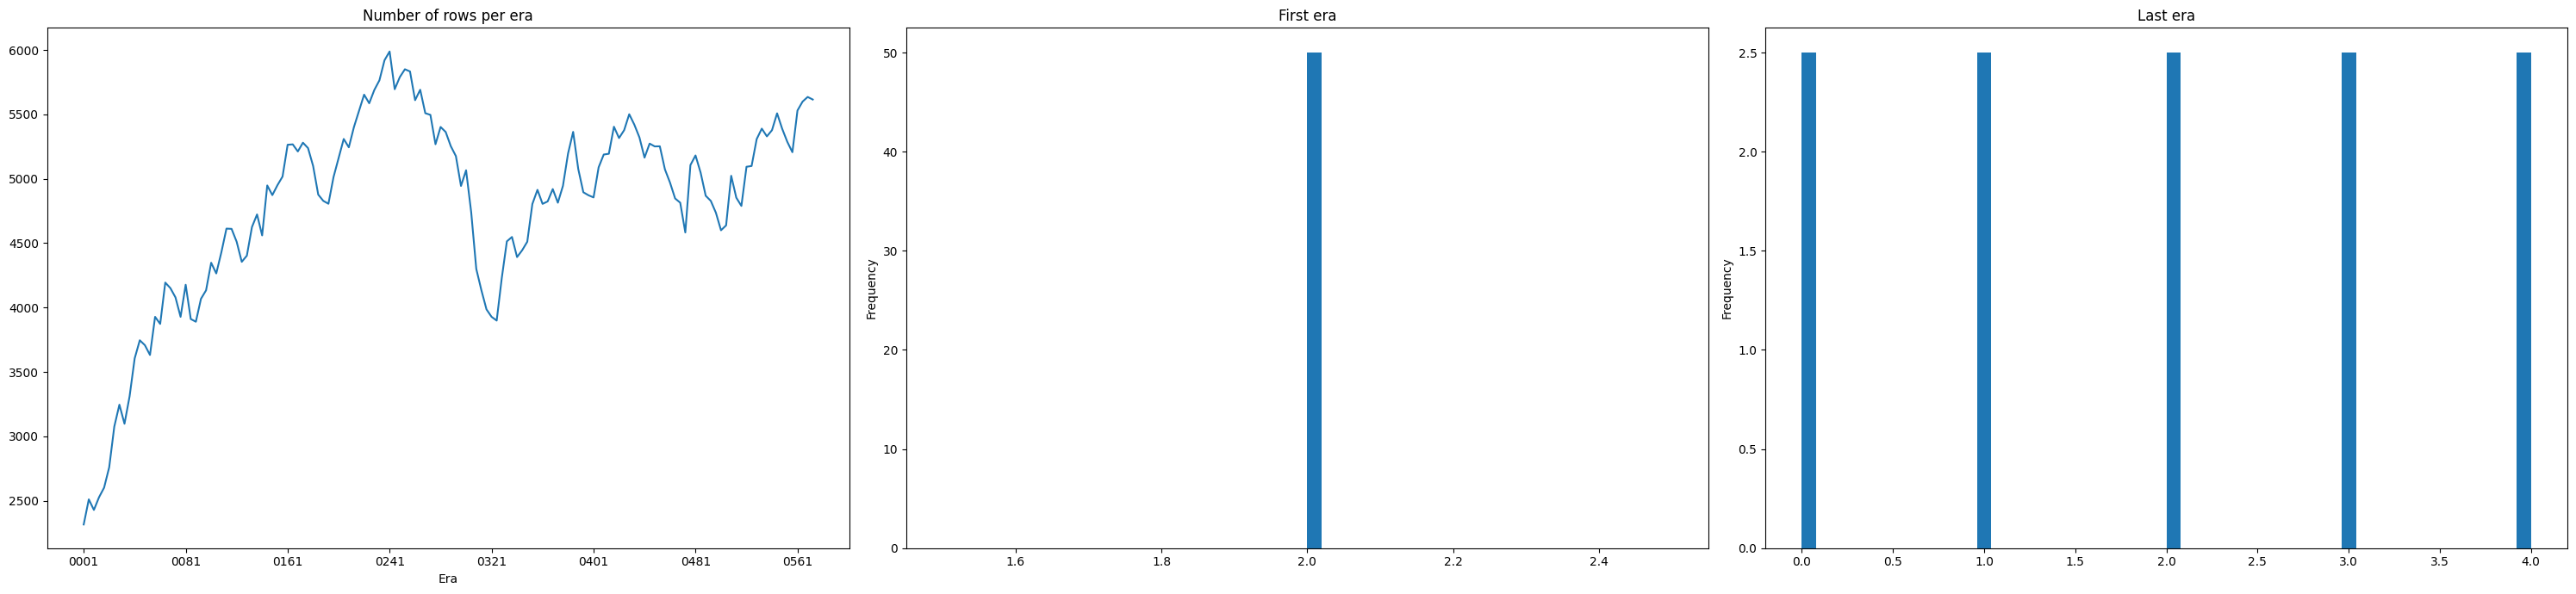

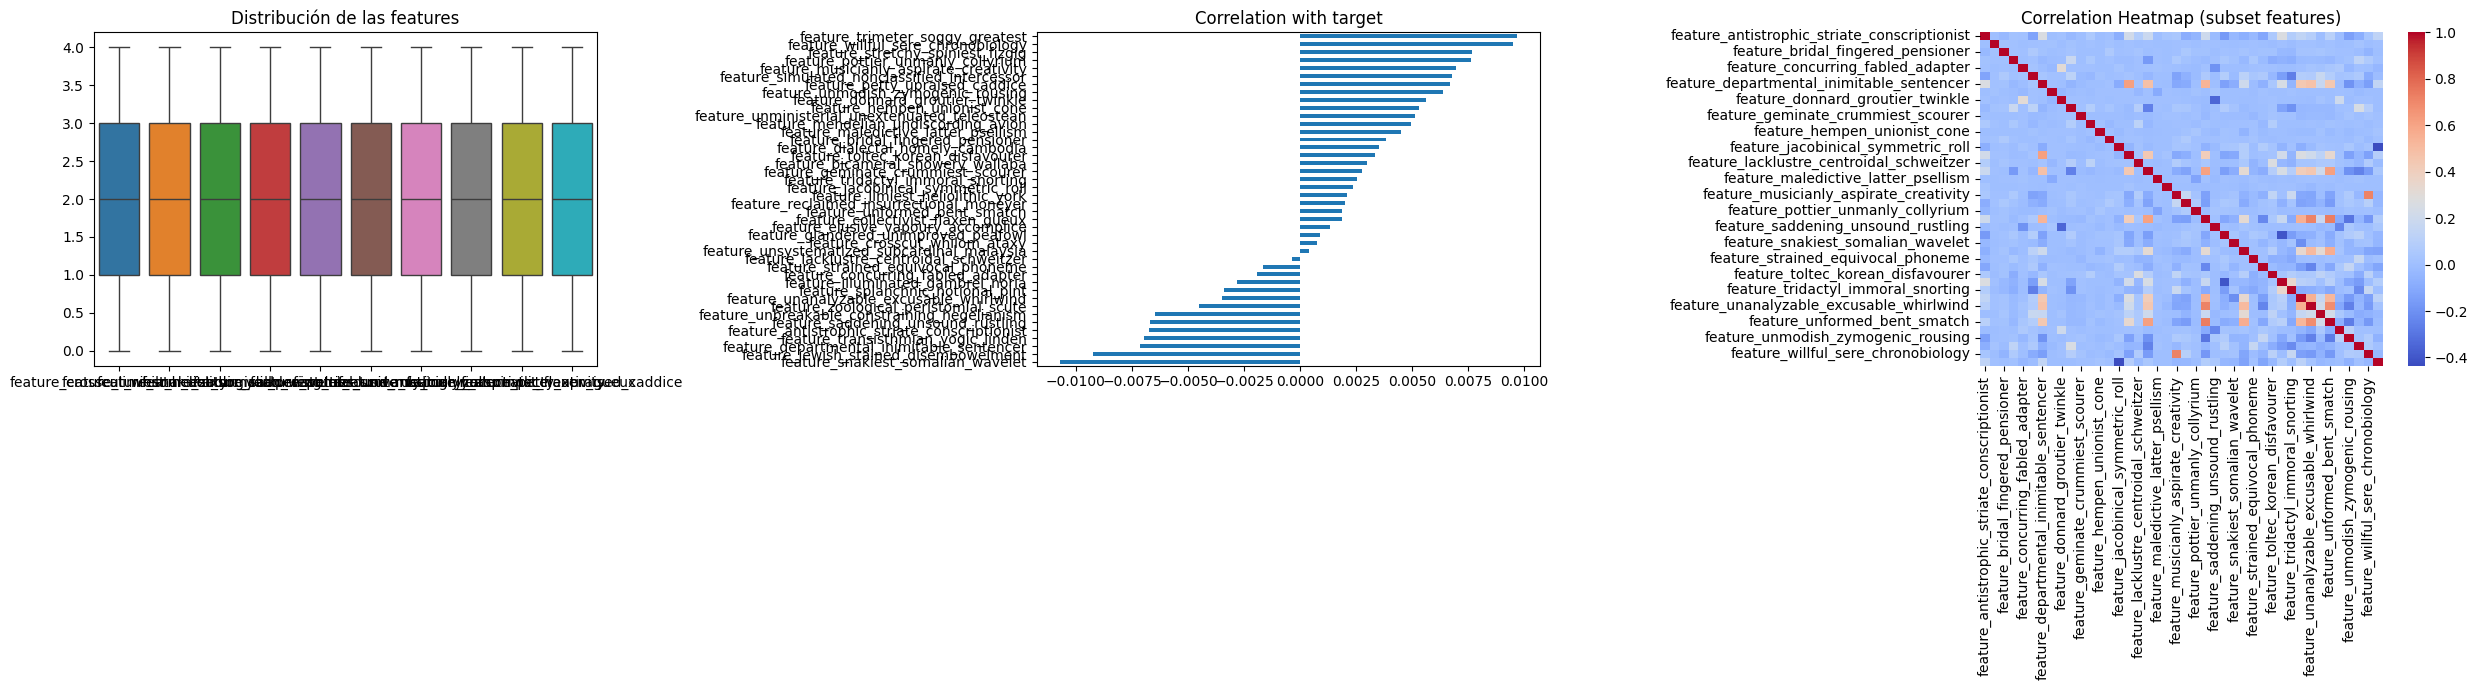

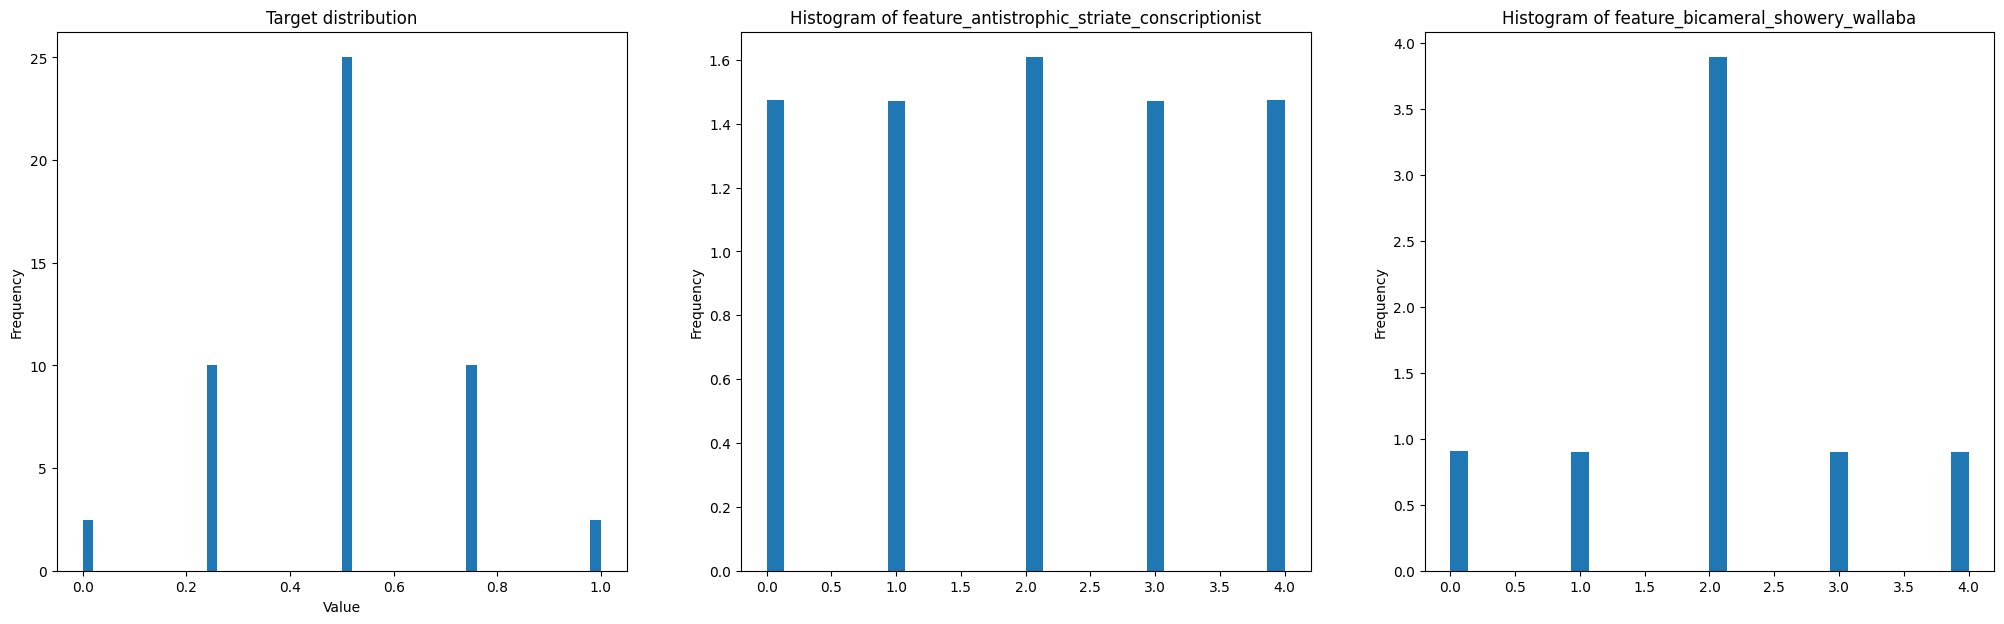

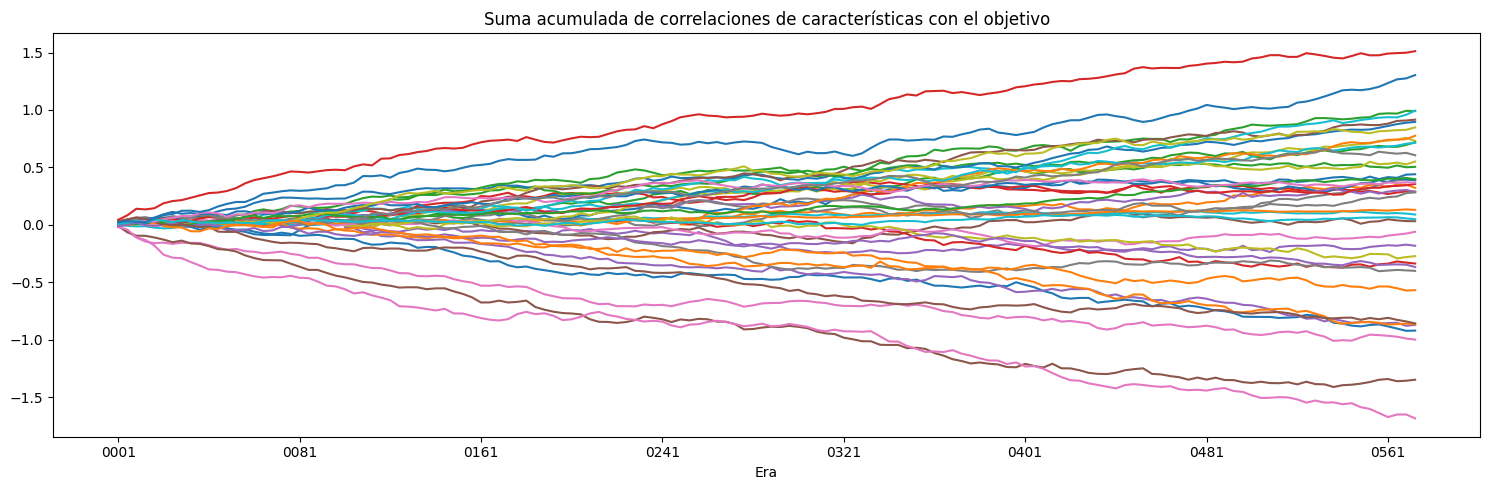

In [69]:

warnings.filterwarnings('ignore')

# Lista de features de interés
attributes = feature_set[:10]
corr_features = ['target'] + feature_set[:42]

# --- Figura 1: Número de filas por era, Histograma primera y última era ---
fig, axes = plt.subplots(1, 3, figsize=(30, 7))

train.groupby("era").size().plot(ax=axes[0], title="Number of rows per era")
axes[0].set_xlabel("Era")

first_era = train[train["era"] == train["era"].unique()[0]]
first_era[feature_set[-1]].plot(kind="hist", bins=50, density=True, ax=axes[1], title="First era")

last_era = train[train["era"] == train["era"].unique()[-1]]
last_era[feature_set[-1]].plot(kind="hist", bins=50, density=True, ax=axes[2], title="Last era")

plt.tight_layout()
plt.show()

# --- Figura 2: Histograma target, correlación con target, heatmap subset ---
fig, axes = plt.subplots(1, 3, figsize=(25, 7))

random_features = np.random.choice(feature_set, size=10, replace=False)
sns.boxplot(data=train[random_features], ax=axes[0])
axes[0].set_title("Distribución de las features")

corr = train[corr_features].corr()["target"].drop("target")
corr.sort_values().plot.barh(ax=axes[1], title="Correlation with target")

sns.heatmap(train[feature_set].corr(), cmap="coolwarm", ax=axes[2])
axes[2].set_title("Correlation Heatmap (subset features)")

plt.tight_layout()
plt.show()

# --- Figura 3: Boxplot por era y histogramas múltiples ---
fig, axes = plt.subplots(1, 3, figsize=(25, 7))

train["target"].plot(kind="hist", bins=50, density=True, ax=axes[0], title="Target distribution")
axes[0].set_xlabel("Value")

for i, feature in enumerate(feature_set[:2]):  # Limito a 2 para que quepa
    train[feature].plot(kind="hist", bins=30, density=True, ax=axes[i+1], title=f"Histogram of {feature}")


# --- Figura 4: Correlaciones por era ---
fig, ax = plt.subplots(figsize=(15, 5))
per_era_corrs = pd.DataFrame(index=train.era.unique())
for feature_name in feature_set:
    per_era_corrs[feature_name] = train.groupby("era").apply(lambda d: practica_corr(d[feature_name], d["target"]))
per_era_corrs.cumsum().plot(ax=ax, title="Suma acumulada de correlaciones de características con el objetivo", legend=False, xlabel="Era");

plt.tight_layout()
plt.show()


### Reducción del conjunto de datos:

Al usar un set de features '`small`' no es necesario eliminar filas, ya que el entrenamiento no es muy pesado

Ahora bien, si se usara el features '`all`' podría considerarse coger un set de `[:5000]` filas para reducir el tiempo de entrenamiento. Aunque se perdería información, se ganaría en velocidad de experimentación.

### Selección de características

#### Métodos usados

- Selección inicial: se usan las features numéricas definidas en `feature_set`.  
- Filtrado por varianza: se eliminan features con varianza ≤ 0.5 (reducción de variables poco informativas).  
- Filtrado por correlación con el target: se mantienen solo las features con correlación > 0 respecto a `target` (variables relevantes).
- Eliminación de multicolinealidad: para pares de features con correlación absoluta > 0.9 se elimina una de las dos (se prefiere conservar la que no aparece como repetida en el bucle).  
- Resultado actual: 28 features seleccionadas (pueden ajustarse umbrales para obtener más/menos features).  

Notas:
- Los umbrales son heurísticos y pueden ajustarse según validación cruzada.

In [70]:
# Dividimos los datos de entrenamiento en features y target
X_dsTrain = train[feature_set]
y_dsTrain = train["target"]

# Filtramos por varianza > 0.5
feature_variances = X_dsTrain.var()
features_var = feature_variances[feature_variances > 0.5].index.tolist()
print(f"Features con varianza > 0.5: {len(features_var)}")

# Filtramos por correlación positiva con target
corr_with_target = X_dsTrain[features_var].corrwith(y_dsTrain)
features_corr_pos = corr_with_target[corr_with_target > 0].index.tolist()
print(f"Features con correlación positiva con target: {len(features_corr_pos)}")

#Quitar features altamente correlacionadas entre sí
X_filtered = X_dsTrain[features_corr_pos].copy()
corr_matrix = X_filtered.corr().abs()

# Definir umbral de correlación alta (ej. 0.9)
threshold = 0.9

# Creamos un conjunto de features a eliminar
to_drop = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            colname = corr_matrix.columns[i]
            to_drop.add(colname)

# Features finales
selected_features = [f for f in features_corr_pos if f not in to_drop]
print(f"Features finales seleccionadas: {len(selected_features)}")


Features con varianza > 0.5: 42
Features con correlación positiva con target: 28
Features finales seleccionadas: 28


#### Podemos visualizar la suma acumulada de correlaciones de las features seleccionadas con el target, viendo que ahora, tras la selección, todas tienen correlación positiva.

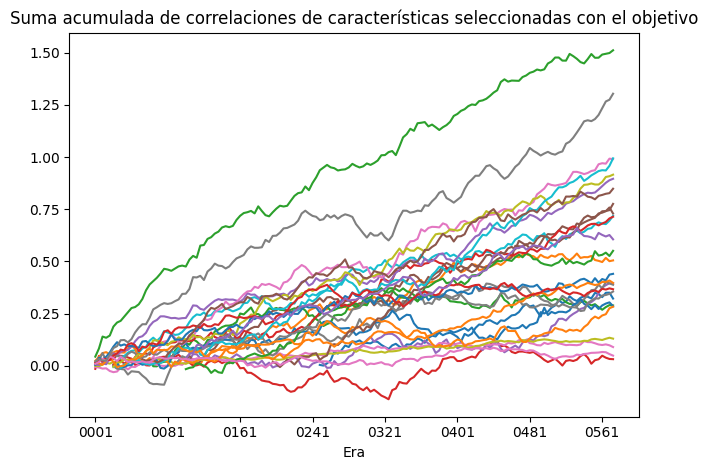

In [71]:
per_era_corrs = pd.DataFrame(index=train.era.unique())
for feature_name in features_corr_pos:
    per_era_corrs[feature_name] = train.groupby("era").apply(lambda d: practica_corr(d[feature_name], d["target"]))
per_era_corrs.cumsum().plot(title="Suma acumulada de correlaciones de características seleccionadas con el objetivo", legend=False, xlabel="Era");
plt.tight_layout()
plt.show()


### PCA para reducción de dimensionalidad

In [72]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.98)
X_pca = pca.fit_transform(X_dsTrain)
print(f"Explained variance ratio by 2 components: {pca.explained_variance_ratio_}")
print(f"Number of components to retain 98% variance: {pca.n_components_}")

Explained variance ratio by 2 components: [0.12240429 0.05777404 0.04638805 0.04277695 0.03804882 0.03332281
 0.03138967 0.03082462 0.02744617 0.02640045 0.02590674 0.02512867
 0.02460208 0.02458792 0.02392639 0.02289798 0.02269223 0.02170334
 0.02143608 0.02104948 0.02092549 0.01955674 0.01896435 0.01865643
 0.01792453 0.0177575  0.01718709 0.01653911 0.01615292 0.01551374
 0.01525542 0.01508041 0.01413683 0.01362583 0.01305397 0.01230919
 0.01179534 0.01021452 0.00778643]
Number of components to retain 98% variance: 39


Con un 98% de varianza explicada, se reducen las features a 39 componentes principales, lo que simplifica el modelo y puede mejorar la generalización. Eso quiero decir que hay 3 features originales que aportan muy poca información.

### Preprocesamiento final

Al ser las features ya estandarizadas, **no es necesario aplicar escalado adicional**. El conjunto de datos está listo para el entrenamiento del modelo.

**Prueba realizada**

 Se aplicó **MinMaxScaler** a las features para llevarlas al rango `[0, 1]`. Sin embargo, se obtuvieron las mismas métricas que sin escalado, por lo que se decidió no usarlo.

 ```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_dsTrain_reset = X_dsTrain.reset_index(drop=True)
X_dsTrain_scaler = scaler.fit_transform(X_dsTrain_reset)
X_dsTrain_scaler = pd.DataFrame(X_dsTrain_scaler, columns=feature_set, index=X_dsTrain.index)
X_dsTrain_scaler.head()
 ```

## 2. Selección y Entrenamiento de Modelos

### 2.1 Modelo LGBMRegressor

Primero dividiremos los datos de entrenamiento en entrenamiento y test usando `train_test_split` de sklearn.

Se cogerá un 80% para entrenamiento y un 20% para test.

In [73]:
# Division del conjunto train.parquet en train y test sets

# Modelo LGBMRegressor con todas las features iniciales del conjunto 'small'.
X_trainLGBM1, X_testLGBM1, y_trainLGBM1, y_testLGBM1 = train_test_split(X_dsTrain, y_dsTrain, test_size=0.2, random_state=42)

# Modelo LGBMRegressor con las features seleccionadas tras el análisis previo.
X_trainLGBM2, X_testLGBM2, y_trainLGBM2, y_testLGBM2 = train_test_split(X_dsTrain[selected_features], y_dsTrain, test_size=0.2, random_state=42)

# Modelo LGBMRegressor con las features resultantes del PCA.
X_trainLGBM3, X_testLGBM3, y_trainLGBM3, y_testLGBM3 = train_test_split(pd.DataFrame(X_pca), y_dsTrain, test_size=0.2, random_state=42)


Entrenamiento del modelo LGBMRegressor con todas las features iniciales del conjunto 'small'.

In [74]:
warnings.filterwarnings('ignore')
# Entrenamiento del modelo LGBMRegressor con todas las features iniciales del conjunto 'small'.
modelLGBM1 = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  n_jobs=-1
)

modelLGBM1.fit(
  X_trainLGBM1,
  y_trainLGBM1
);


# Entrenamiento del modelo LGBMRegressor con las features seleccionadas tras el análisis previo.
modelLGBM2 = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1,
  n_jobs=-1
)

modelLGBM2.fit(
  X_trainLGBM2,
  y_trainLGBM2
);


# Entrenamiento del modelo LGBMRegressor con las features restantes tras aplicar PCA.
modelLGBM3 = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1,
  n_jobs=-1
)

modelLGBM3.fit(
  X_trainLGBM3,
  y_trainLGBM3
);

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010449 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 550547, number of used features: 42
[LightGBM] [Info] Start training from score 0.499988
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 140
[LightGBM] [Info] Number of data points in the train set: 550547, number of used features: 28
[LightGBM] [Info] Start training from score 0.499988
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

In [75]:
print(f"Longitud de las importancias de las características del modelo LGBM1: {modelLGBM1.feature_importances_.__len__()}")
print(f"Longitud de las importancias de las características del modelo LGBM2: {modelLGBM2.feature_importances_.__len__()}")
print(f"Longitud de las importancias de las características del modelo LGBM3: {modelLGBM3.feature_importances_.__len__()}")

print(f"Longitud de los feature sets utilizados:\n- Modelo LGBM1: {X_dsTrain.shape[1]} features\n- Modelo LGBM2: {len(selected_features)} features\n- Modelo LGBM3: {X_pca.shape[1]} features")

Longitud de las importancias de las características del modelo LGBM1: 42
Longitud de las importancias de las características del modelo LGBM2: 28
Longitud de las importancias de las características del modelo LGBM3: 39
Longitud de los feature sets utilizados:
- Modelo LGBM1: 42 features
- Modelo LGBM2: 28 features
- Modelo LGBM3: 39 features


Vemos que todas las features que se usan son igual de importantes para el modelo.

### 2.2 Modelo visto en clase - RandomForestRegression (lo entrenaremos con PCA de 2 componentes)

No hemos usado el RandomForestClassifier porque al tratarse de un problema de regresión, no es directamente aplicable. Por tanto usaremos RandomForestRegressor, la versión para regresión del RandomForestClassifier, que es el modelo que vimos en clase.

Lo hemos entrenado con PCA de 2 componentes para reducir la dimensionalidad, lo que puede ayudar a mejorar la eficiencia del modelo y reducir el riesgo de sobreajuste.

Se ha elegido este en lugar de otros modelos vistos en clase (como SVM) porque RandomForest es más robusto a datos ruidosos y puede manejar mejor relaciones no lineales, lo que es beneficioso en problemas de regresión complejos como este. Además, la regresión lineal o logística puede no capturar adecuadamente las complejidades del mercado de valores.

Se han descartado los algoritmos basados en probabilidad como Naive Bayes o KNN, ya que no son adecuados para problemas de regresión continua como este. También se han descartado modelos no descriptivos como KMEANS o DBSCAN, ya que no proporcionan predicciones directas para variables continuas.


In [76]:
pca_randomForest = PCA(n_components=2)
X_pca_randomForest = pca_randomForest.fit_transform(X_dsTrain)

# Realizamos las predicciones en el conjunto de validación
model_randomForest = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_randomForest.fit(X_pca_randomForest, y_dsTrain)


,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 3. Validación del rendimiento

### 3.1 Validación del modelo LGBMRegressor

#### Validación con datos test

In [77]:
# Creamos Series con el índice correcto para cada set de test y las mostramos.
preds1 = pd.Series(modelLGBM1.predict(X_testLGBM1), index=X_testLGBM1.index, name="prediction_LGBM1")
preds2 = pd.Series(modelLGBM2.predict(X_testLGBM2), index=X_testLGBM2.index, name="prediction_LGBM2")
preds3 = pd.Series(modelLGBM3.predict(X_testLGBM3), index=X_testLGBM2.index, name="prediction_LGBM3") # Usamos el mismo índice que X_testLGBM2 ya que X_testLGBM3 no tiene 'era' en el dataframe original

preds4 = pd.Series(modelLGBM1.predict(X_trainLGBM1), index=X_trainLGBM1.index, name="prediction_LGBM1") # Comprobación overfitting


# Resultados para los test splits
results1 = pd.DataFrame({
	"era": train.loc[X_testLGBM1.index, "era"],
	"target": y_testLGBM1,
	"prediction_LGBM1": preds1
})

results2 = pd.DataFrame({
	"era": train.loc[X_testLGBM2.index, "era"],
	"target": y_testLGBM2,
	"prediction_LGBM2": preds2
})


results3 = pd.DataFrame({
	"era": train.loc[X_testLGBM2.index, "era"],
	"target": y_testLGBM3,
	"prediction_LGBM3": preds3
})

# Resultados para el train split (comprobación overfitting modelo LGBM1)
results4 = pd.DataFrame({
	"era": train.loc[X_trainLGBM1.index, "era"],
	"target": y_trainLGBM1,
	"prediction_LGBM1_train": preds4
})
print(f"Results4 dataset: \n {results4.head()}")

metrics_all = pd.concat([results1, results2, results3], axis=1)
display(metrics_all)

Results4 dataset: 
                    era   target  prediction_LGBM1_train
id                                                     
n291299e91f9d85f  0465 0.750000                0.522390
nb859b0df36dc4ec  0353 0.500000                0.507438
nd72439d4e360506  0057 0.750000                0.485864
n439e05f8de9fbd8  0397 0.750000                0.493151
n1d72ba51679573a  0253 0.500000                0.497089


,era,target,prediction_LGBM1,era,target,prediction_LGBM2,era,target,prediction_LGBM3
id,,,,,,,,,
n4049d50cd92e3dc,0245,0.250000,0.489623,0245,0.250000,0.495842,0245,0.250000,0.491795
nfe1b3b03dc16bac,0113,0.250000,0.516618,0113,0.250000,0.507350,0113,0.250000,0.504176
n465278b08b99b97,0505,0.750000,0.522242,0505,0.750000,0.518953,0505,0.750000,0.509204
n6168cfcca279112,0221,0.750000,0.512022,0221,0.750000,0.514761,0221,0.750000,0.503820
neec7ad346c1c115,0257,0.250000,0.512538,0257,0.250000,0.499663,0257,0.250000,0.498783
...,...,...,...,...,...,...,...,...,...
n2eb30978de3df73,0257,0.250000,0.512323,0257,0.250000,0.509624,0257,0.250000,0.500627
n9c924a2b4213c59,0293,0.500000,0.497437,0293,0.500000,0.502223,0293,0.500000,0.499974
n27d0d94f9afbd5b,0465,0.500000,0.500997,0465,0.500000,0.490035,0465,0.500000,0.495350


**Gráficas de correlación por era para los tres modelos**

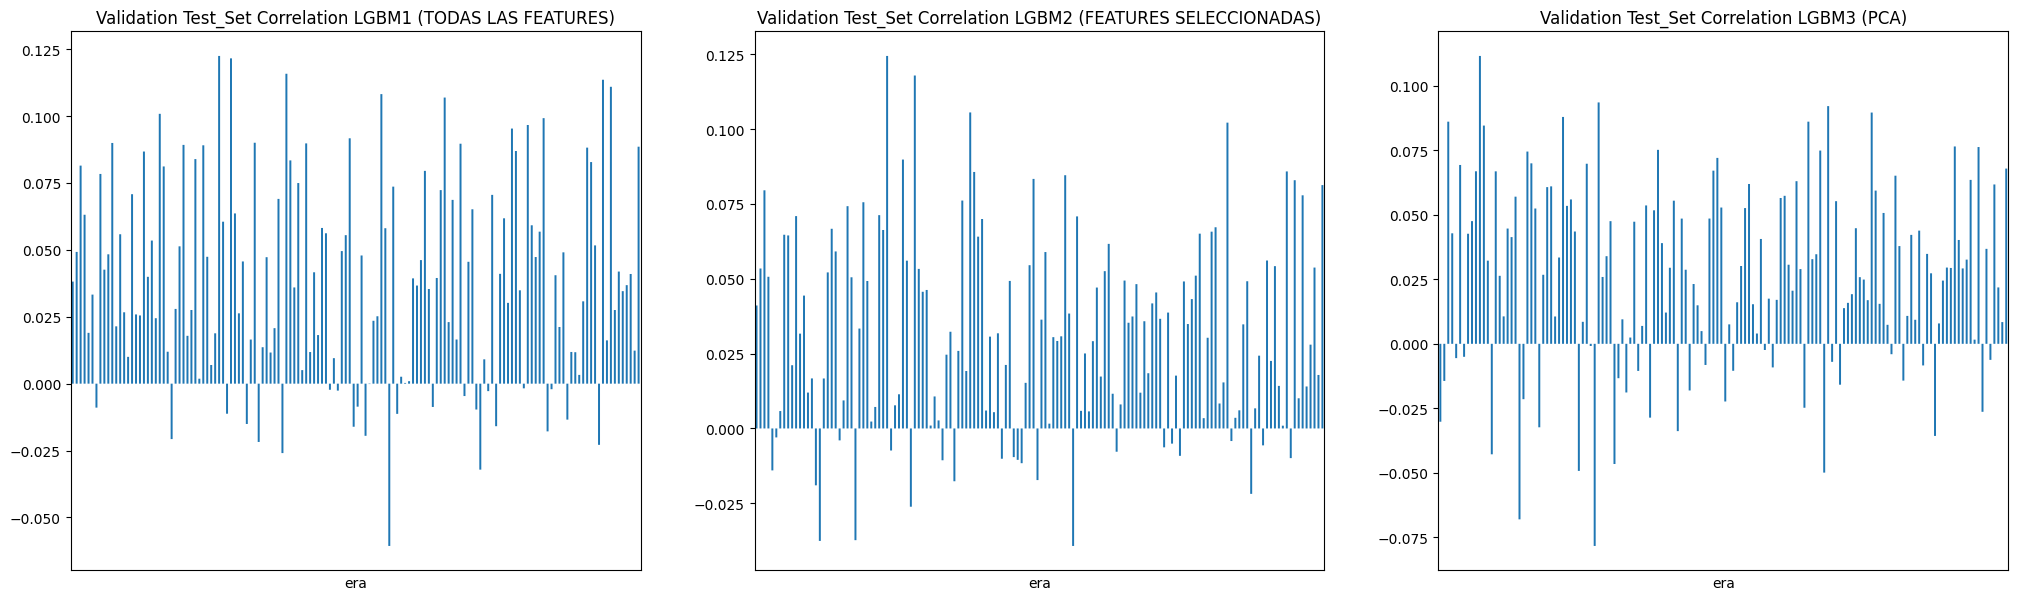

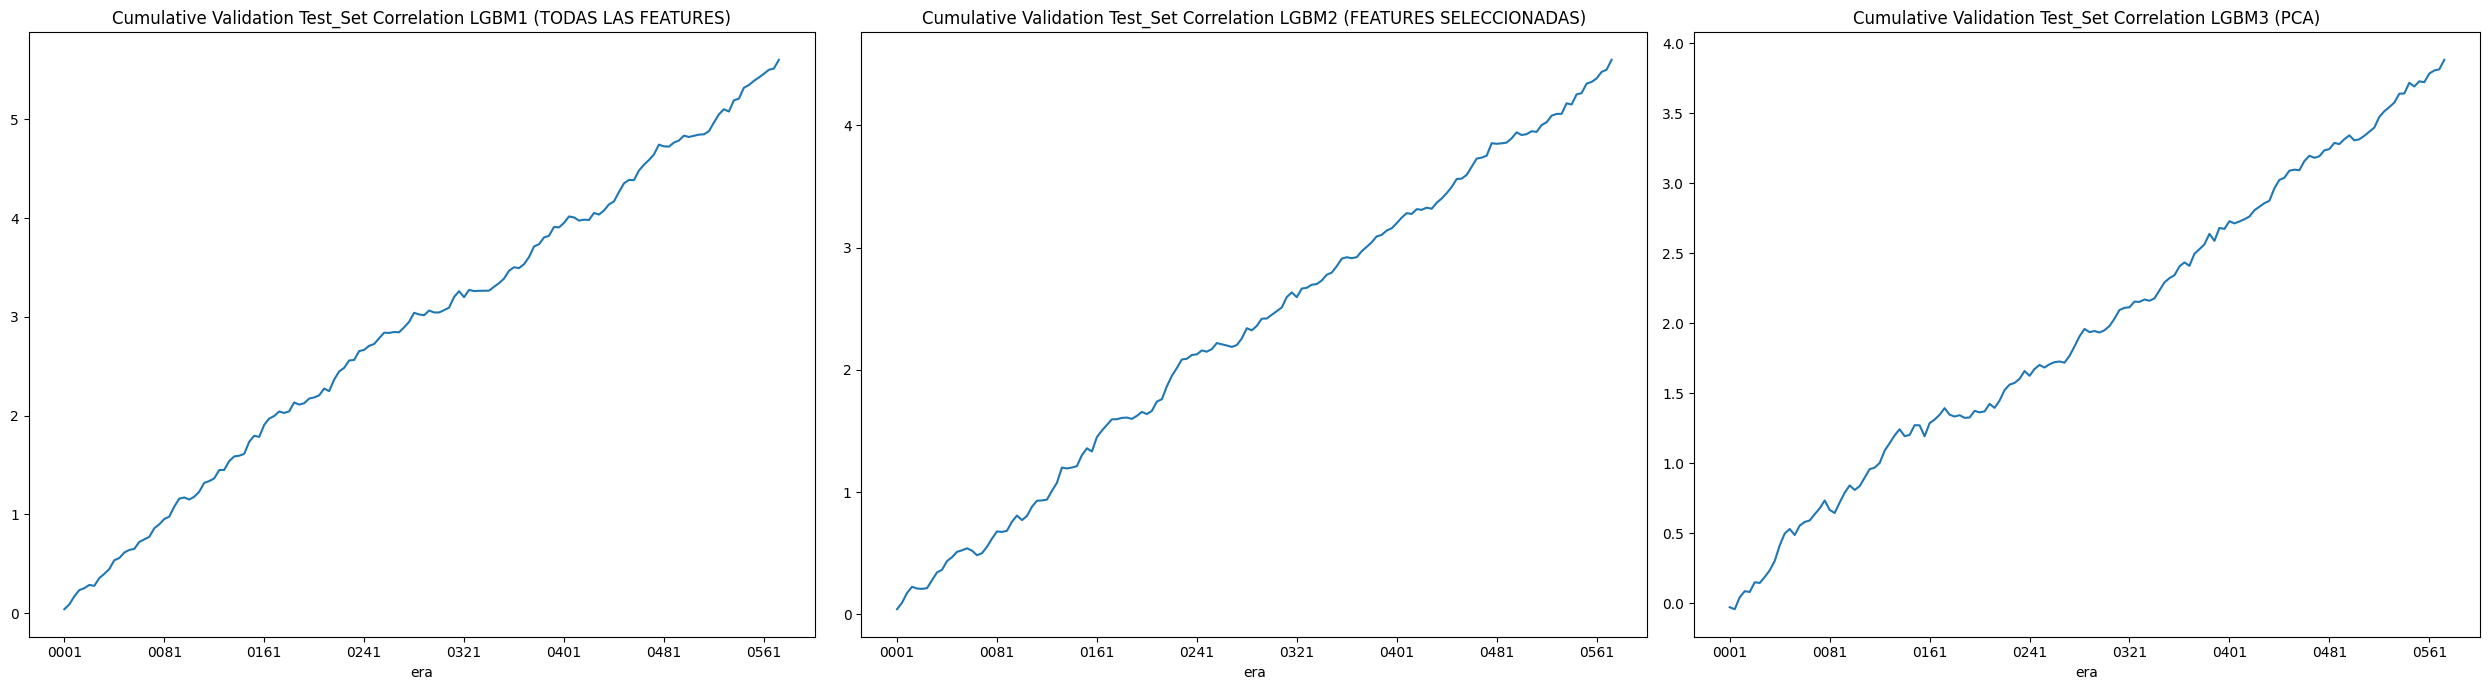

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(25, 7))

# Calcula la correlación por era entre nuestras predicciones y los valores "target".
per_era_corr = results1.groupby("era").apply(lambda x: practica_corr(x["prediction_LGBM1"], x["target"]))
per_era_corr2 = results2.groupby("era").apply(lambda x: practica_corr(x["prediction_LGBM2"], x["target"]))
per_era_corr3 = results3.groupby("era").apply(lambda x: practica_corr(x["prediction_LGBM3"], x["target"]))

# Gráfica de correlación por "era"
per_era_corr.plot(kind="bar", title="Validation Test_Set Correlation LGBM1 (TODAS LAS FEATURES)", xticks=[], snap=False, ax=axes[0]);
per_era_corr2.plot(kind="bar", title="Validation Test_Set Correlation LGBM2 (FEATURES SELECCIONADAS)", xticks=[], snap=False, ax=axes[1]);
per_era_corr3.plot(kind="bar", title="Validation Test_Set Correlation LGBM3 (PCA)", xticks=[], snap=False, ax=axes[2]);

fig, axes = plt.subplots(1, 3, figsize=(25, 7))
per_era_corr.cumsum().plot(kind="line", title="Cumulative Validation Test_Set Correlation LGBM1 (TODAS LAS FEATURES)", ax=axes[0]);
per_era_corr2.cumsum().plot(kind="line", title="Cumulative Validation Test_Set Correlation LGBM2 (FEATURES SELECCIONADAS)", ax=axes[1]);
per_era_corr3.cumsum().plot(kind="line", title="Cumulative Validation Test_Set Correlation LGBM3 (PCA)", ax=axes[2]);
plt.tight_layout()
plt.show()

Se observa que todos los modelos muestran una correlación positiva con el target, lo que indica que están capturando patrones relevantes en los datos. Hay correlación positiva en todas las eras, lo que sugiere que los modelos son consistentes a lo largo del tiempo.

**Métricas de evaluación**

In [79]:
# Calculamos métricas de los 3 modelos
metrics_lgbm1 = compute_metrics(per_era_corr, "LGBM1 (Todas las features)")
metrics_lgbm2 = compute_metrics(per_era_corr2, "LGBM2 (Features seleccionadas)")
metrics_lgbm3 = compute_metrics(per_era_corr3, "LGBM3 (PCA)")

# Métricas para el conjunto de entrenamiento (overfitting check)
metrics_lgbm1_train = compute_metrics(results4.groupby("era").apply(lambda x: practica_corr(x["prediction_LGBM1_train"], x["target"])), "LGBM1 Train (Todas las features) - Overfitting Check")

# Concatenamos los dataframes
metrics_all_test = pd.concat([metrics_lgbm1, metrics_lgbm2, metrics_lgbm3, metrics_lgbm1_train])
display(metrics_all_test)


,mean,std,sharpe,max_drawdown
LGBM1 (Todas las features),0.038903,0.037853,1.027745,0.060683
LGBM2 (Features seleccionadas),0.031509,0.032889,0.958057,0.056581
LGBM3 (PCA),0.026965,0.036000,0.749041,0.089555
LGBM1 Train (Todas las features) - Overfitting Check,0.150441,0.026696,5.635329,0.000000


**Explicación de las métricas:**

**Correlación:** Mide la relación lineal entre las predicciones y los valores reales. Un valor cercano a 1 indica una fuerte correlación positiva.  
**Mean:** Promedio de las predicciones. Indica el valor medio que el modelo predice.  
**Std:** Desviación estándar de las predicciones. Mide la variabilidad de las predicciones.  
**Sharpe:** Ratio de Sharpe, que mide el rendimiento ajustado al riesgo. Se calcula como la media de las predicciones dividida por su desviación estándar. Un valor más alto indica un mejor rendimiento ajustado al riesgo.  
**Max Drawdown:** Máxima caída desde un pico hasta un valle en las predicciones. Debe ser lo más bajo posible, ya que indica la peor pérdida potencial.

### F1 Score vs Coeficiente de Pearson

El **coeficiente de correlación de Pearson** mide la relación lineal entre los valores predichos por el modelo y los valores reales.
Es una métrica adecuada para **problemas de regresión**, donde el objetivo es que las **predicciones sigan la misma tendencia que los valores verdaderos** (es decir, *cuando uno aumenta, el otro también*).

En cambio, el **F1 Score** es una métrica utilizada en **problemas de clasificación**, especialmente cuando hay clases desbalanceadas.
Evalúa la precisión y la exhaustividad (recall) del modelo combinándolas en una sola medida.
Por lo tanto, el **F1 Score no tiene sentido en un contexto de regresión**, ya que no existen clases discretas sino valores continuos.

En nuestro caso, al tratarse de un problema de regresión (*como ocurre en muchos contextos financieros*), lo importante es medir qué tan alineadas están las predicciones con las observaciones reales.
Por ello, ***el coeficiente de Pearson —junto con métricas como mean correlation, standard deviation, Sharpe ratio y max drawdown— resulta más adecuado*** para evaluar la consistencia y estabilidad del modelo a lo largo de las distintas eras o periodos de tiempo.

Igualmente podemos probar de calcular el F1 Score tras convertir las predicciones en categorías (por ejemplo, usando un umbral para clasificar en positivo/negativo), pero esto no es lo ideal para un problema de regresión.

In [80]:
# Cálculo del F1 Score para cada modelo, binarizando las predicciones y los targets.
binarizer = Binarizer(threshold=0.5)
y_testLGBM1_binarized = binarizer.fit_transform(y_testLGBM1.values.reshape(-1, 1)).flatten()
y_testLGBM2_binarized = binarizer.fit_transform(y_testLGBM2.values.reshape(-1, 1)).flatten()
y_testLGBM3_binarized = binarizer.fit_transform(y_testLGBM3.values.reshape(-1, 1)).flatten()
y_trainLGBM1_binarized = binarizer.fit_transform(y_trainLGBM1.values.reshape(-1, 1)).flatten()

preds1_binarized = binarizer.transform(preds1.values.reshape(-1, 1)).flatten()
preds2_binarized = binarizer.transform(preds2.values.reshape(-1, 1)).flatten()
preds3_binarized = binarizer.transform(preds3.values.reshape(-1, 1)).flatten()
preds4_binarized = binarizer.transform(preds4.values.reshape(-1, 1)).flatten()

# Calculate F1 scores
print(f"F1 Score (LGBM1): {f1_score(y_testLGBM1_binarized, preds1_binarized, average='weighted')}")
print(f"F1 Score (LGBM2): {f1_score(y_testLGBM2_binarized, preds2_binarized, average='weighted')}")
print(f"F1 Score (LGBM3): {f1_score(y_testLGBM3_binarized, preds3_binarized, average='weighted')}")
print(f"F1 Score (LGBM1 Train): {f1_score(y_trainLGBM1_binarized, preds4_binarized, average='weighted')}")

F1 Score (LGBM1): 0.5473290306537317
F1 Score (LGBM2): 0.5527302128404935
F1 Score (LGBM3): 0.5402103752896907
F1 Score (LGBM1 Train): 0.5749252415647851


#### Validación con validation.parquet

In [81]:
X_dsValidation = validation[feature_set]
y_dsValidation = validation["target"]

preds1_validation = pd.Series(modelLGBM1.predict(X_dsValidation), index=X_dsValidation.index, name="prediction_LGBM1")
preds2_validation = pd.Series(modelLGBM2.predict(X_dsValidation[selected_features]), index=X_dsValidation.index, name="prediction_LGBM2")
X_validation_pca = pca.transform(X_dsValidation)
preds3_validation = pd.Series(modelLGBM3.predict(pd.DataFrame(X_validation_pca)), index=X_dsValidation.index, name="prediction_LGBM3")

results1_validation = pd.DataFrame({
	"era": validation.loc[X_dsValidation.index, "era"],
	"target": y_dsValidation,
	"prediction_LGBM1": preds1_validation
})

results2_validation = pd.DataFrame({
	"era": validation.loc[X_dsValidation.index, "era"],
	"target": y_dsValidation,
	"prediction_LGBM2": preds2_validation
})

results3_validation = pd.DataFrame({
	"era": validation.loc[X_dsValidation.index, "era"],
	"target": y_dsValidation,
	"prediction_LGBM3": preds3_validation
})

metrics_all = pd.concat([results1_validation, results2_validation, results3_validation], axis=1)
display(metrics_all)

,era,target,prediction_LGBM1,era,target,prediction_LGBM2,era,target,prediction_LGBM3
id,,,,,,,,,
n0003806f5bad605,0577,0.500000,0.504472,0577,0.500000,0.497192,0577,0.500000,0.503588
n000be59a0bee991,0577,0.750000,0.502493,0577,0.750000,0.499577,0577,0.750000,0.495661
n00140a076404e34,0577,0.500000,0.505110,0577,0.500000,0.497493,0577,0.500000,0.498814
n0026f6c0fbc483a,0577,0.250000,0.495465,0577,0.250000,0.497381,0577,0.250000,0.500010
n002b74421382a36,0577,0.250000,0.504587,0577,0.250000,0.511935,0577,0.250000,0.504361
...,...,...,...,...,...,...,...,...,...
nffce4965d071060,1186,1.000000,0.507205,1186,1.000000,0.509668,1186,1.000000,0.504785
nffe1d70e1a2e6b0,1186,0.500000,0.503974,1186,0.500000,0.489835,1186,0.500000,0.500777
nffe4ecb4dc62e91,1186,0.500000,0.500134,1186,0.500000,0.499870,1186,0.500000,0.496509


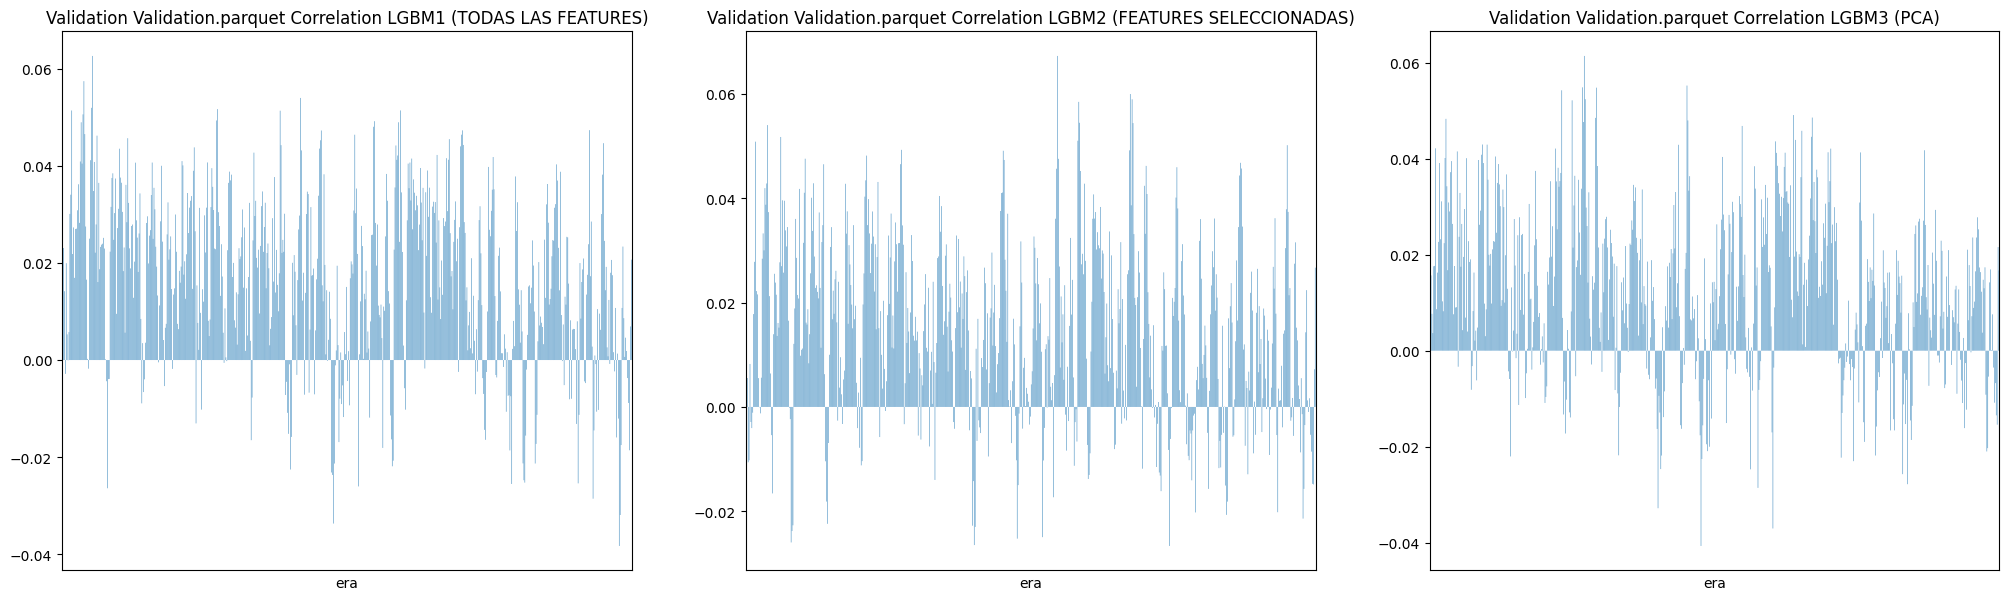

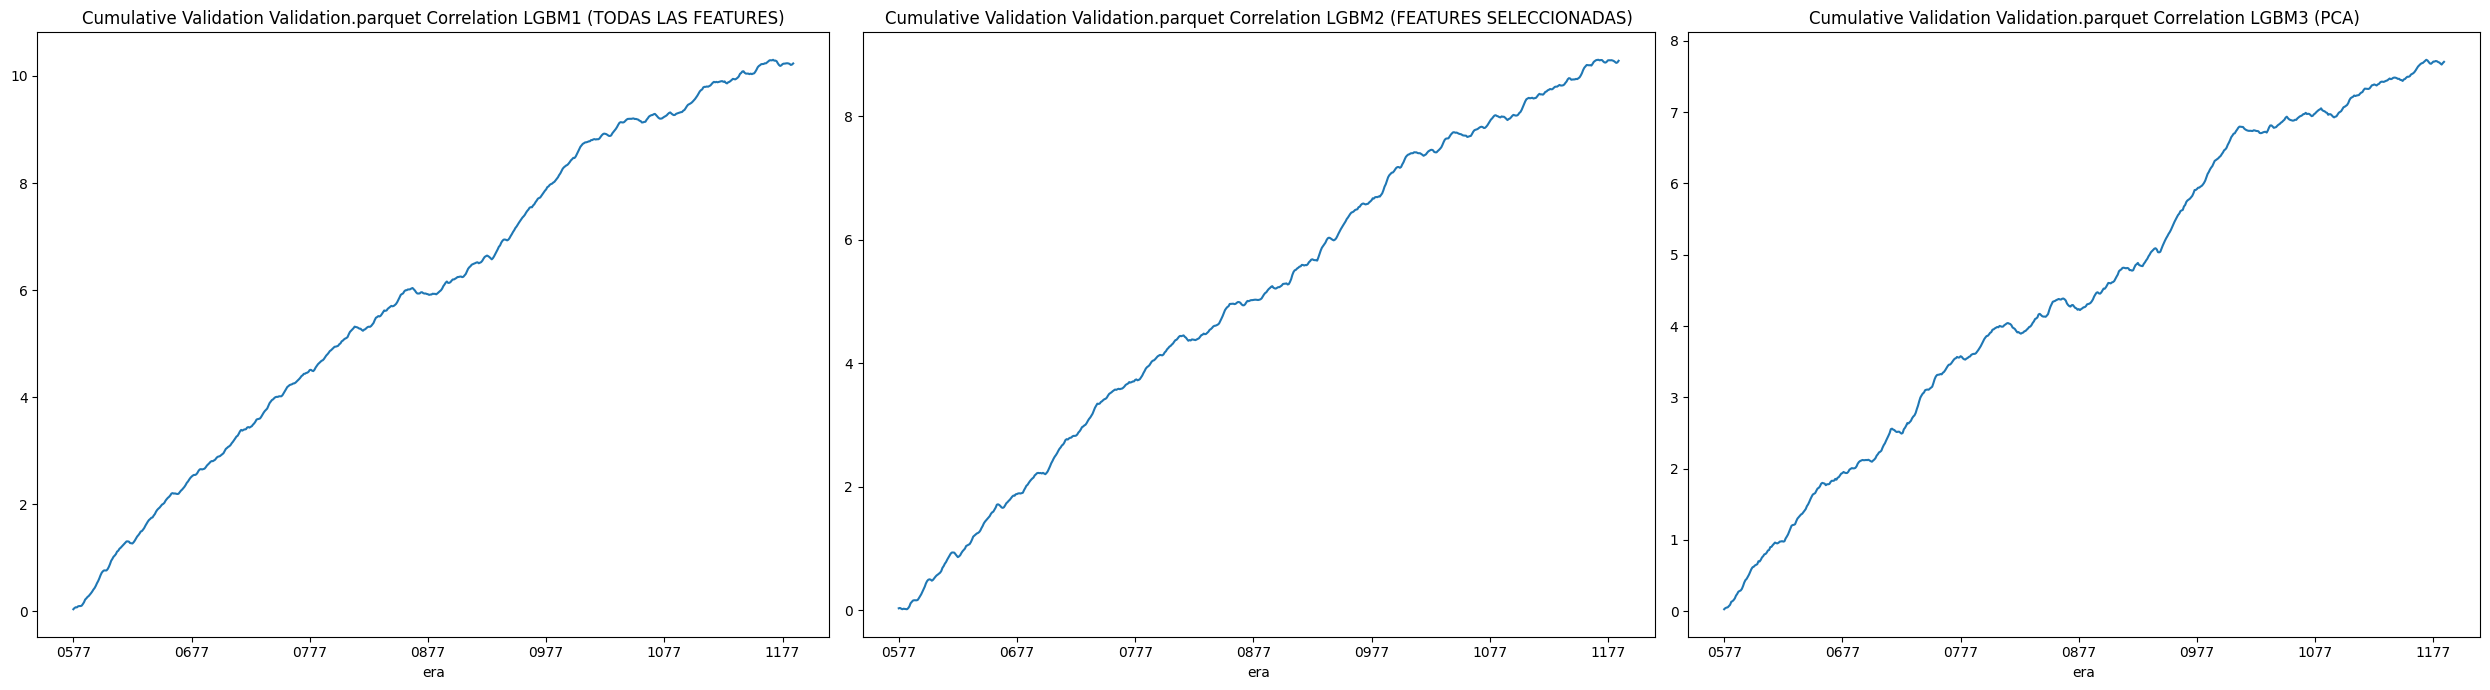

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(25, 7))

# Calcula la correlación por era entre nuestras predicciones y los valores "target".
per_era_corr_validation = results1_validation.groupby("era").apply(lambda x: practica_corr(x["prediction_LGBM1"], x["target"]))
per_era_corr2_validation = results2_validation.groupby("era").apply(lambda x: practica_corr(x["prediction_LGBM2"], x["target"]))
per_era_corr3_validation = results3_validation.groupby("era").apply(lambda x: practica_corr(x["prediction_LGBM3"], x["target"]))

# Gráfica de correlación por "era"
per_era_corr_validation.plot(kind="bar", title="Validation Validation.parquet Correlation LGBM1 (TODAS LAS FEATURES)", xticks=[], snap=False, ax=axes[0]);
per_era_corr2_validation.plot(kind="bar", title="Validation Validation.parquet Correlation LGBM2 (FEATURES SELECCIONADAS)", xticks=[], snap=False, ax=axes[1]);
per_era_corr3_validation.plot(kind="bar", title="Validation Validation.parquet Correlation LGBM3 (PCA)", xticks=[], snap=False, ax=axes[2]);

fig, axes = plt.subplots(1, 3, figsize=(25, 7))
per_era_corr_validation.cumsum().plot(kind="line", title="Cumulative Validation Validation.parquet Correlation LGBM1 (TODAS LAS FEATURES)", ax=axes[0]);
per_era_corr2_validation.cumsum().plot(kind="line", title="Cumulative Validation Validation.parquet Correlation LGBM2 (FEATURES SELECCIONADAS)", ax=axes[1]);
per_era_corr3_validation.cumsum().plot(kind="line", title="Cumulative Validation Validation.parquet Correlation LGBM3 (PCA)", ax=axes[2]);
plt.tight_layout()
plt.show();

Se observa que todos los modelos muestran una correlación positiva con el target, lo que indica que están capturando patrones relevantes en los datos. Hay correlación positiva en todas las eras, lo que sugiere que los modelos son consistentes a lo largo del tiempo.

In [83]:
# Calculamos métricas de los 3 modelos
metrics_lgbm1 = compute_metrics(per_era_corr_validation, "LGBM1 (Todas las features) Validation.parquet")
metrics_lgbm2 = compute_metrics(per_era_corr2_validation, "LGBM2 (Features seleccionadas) Validation.parquet")
metrics_lgbm3 = compute_metrics(per_era_corr3_validation, "LGBM3 (PCA) Validation.parquet")

# Concatenamos los dataframes
metrics_all_validation = pd.concat([metrics_lgbm1, metrics_lgbm2, metrics_lgbm3])
display(metrics_all_validation)

,mean,std,sharpe,max_drawdown
LGBM1 (Todas las features) Validation.parquet,0.016777,0.017464,0.960704,0.127765
LGBM2 (Features seleccionadas) Validation.parquet,0.014581,0.017112,0.852105,0.086379
LGBM3 (PCA) Validation.parquet,0.012634,0.017075,0.739894,0.161944


### 3.2 Validación del modelo RandomForestRegressor visto en clase

Para validar el modelo hemos calculado el f1 Score en el conjunto de validación y en el conjunto de entrenamiento. Por ello se ha tenido que binarizar tanto las predicciones como los valores reales del target. También hemos calculado las métricas de mean, std, sharpe y max drawdown.

#### Validación con datos test

In [84]:
X_testLGBM1_pca = pca_randomForest.transform(X_testLGBM1)
preds_randomForest = pd.Series(model_randomForest.predict(X_testLGBM1_pca), index=X_testLGBM1.index, name="prediction_RandomForest")

# Binarize the target and predictions
binarizer = Binarizer(threshold=0.5)
y_test_binarized = binarizer.fit_transform(y_testLGBM1.values.reshape(-1, 1)).flatten()
preds_binarized = binarizer.transform(preds_randomForest.values.reshape(-1, 1)).flatten()

# Reporte de clasificación para el modelo SVM
print("Reporte de clasificación para el modelo SVM:")
print(classification_report(y_test_binarized, preds_binarized))

metrics_randomForest_test = compute_metrics(results1.groupby("era").apply(lambda x: practica_corr(preds_randomForest.loc[x.index], x["target"])), "Random Forest (PCA)")
display(metrics_randomForest_test)

Reporte de clasificación para el modelo SVM:
              precision    recall  f1-score   support

         0.0       0.77      0.73      0.75    103222
         1.0       0.29      0.33      0.31     34415

    accuracy                           0.63    137637
   macro avg       0.53      0.53      0.53    137637
weighted avg       0.65      0.63      0.64    137637



,mean,std,sharpe,max_drawdown
Random Forest (PCA),0.037850,0.036171,1.046420,0.124810


In [85]:
# Comprobación de overfitting en el conjunto de entrenamiento
preds_randomForest = pd.Series(model_randomForest.predict(X_pca_randomForest),index=X_dsTrain.index, name="prediction_RandomForest")

# Binarize the target and predictions
binarizer = Binarizer(threshold=0.5)
y_dsTrain_binarized = binarizer.fit_transform(y_dsTrain.values.reshape(-1, 1)).flatten()
preds_binarized = binarizer.transform(preds_randomForest.values.reshape(-1, 1)).flatten()

# Reporte de clasificación para el modelo SVM
print("Reporte de clasificación para el modelo SVM:")
print(classification_report(y_dsTrain_binarized, preds_binarized))


metrics = compute_metrics(results4.groupby("era").apply(lambda x: practica_corr(preds_randomForest.loc[x.index], x["target"])), "Random Forest Train (PCA) - Overfitting Check")
display(metrics)

Reporte de clasificación para el modelo SVM:
              precision    recall  f1-score   support

         0.0       0.77      0.73      0.75    516178
         1.0       0.29      0.32      0.31    172006

    accuracy                           0.63    688184
   macro avg       0.53      0.53      0.53    688184
weighted avg       0.65      0.63      0.64    688184



,mean,std,sharpe,max_drawdown
Random Forest Train (PCA) - Overfitting Check,0.036305,0.021766,1.667967,0.019485


#### Validación con datos validation.parquet

In [86]:
X_validation_pca = pca_randomForest.transform(X_dsValidation)
preds_randomForest = pd.Series(model_randomForest.predict(X_validation_pca), index=X_dsValidation.index, name="prediction_RandomForest")

# Binarize the target and predictions
binarizer = Binarizer(threshold=0.5)
y_validation_binarized = binarizer.fit_transform(y_dsValidation.values.reshape(-1, 1)).flatten()
preds_binarized = binarizer.transform(preds_randomForest.values.reshape(-1, 1)).flatten()

# Reporte de clasificación para el modelo SVM
print("Reporte de clasificación para el modelo SVM:")
print(classification_report(y_validation_binarized, preds_binarized))

# Métricas para el conjunto de validación
metrics_randomForest_validation = compute_metrics(validation.groupby("era").apply(lambda x: practica_corr(preds_randomForest.loc[x.index], x["target"])), "Random Forest Validation.parquet (PCA)")
display(metrics_randomForest_validation)

Reporte de clasificación para el modelo SVM:
              precision    recall  f1-score   support

         0.0       0.76      0.72      0.74   2836575
         1.0       0.28      0.32      0.30    945666

    accuracy                           0.62   3782241
   macro avg       0.52      0.52      0.52   3782241
weighted avg       0.64      0.62      0.63   3782241



,mean,std,sharpe,max_drawdown
Random Forest Validation.parquet (PCA),0.007025,0.017091,0.411063,0.261191


Vemos que el modelo RandomForestRegressor si presenta overfitting, ya que las métricas en el conjunto de entrenamiento son significativamente mejores que en el conjunto de validación. También entre el conjunto de entrenamiento y el de test. Esto indica que el modelo ha aprendido patrones específicos del conjunto de entrenamiento que no se generalizan bien a datos nuevos.

Además las métricas obtenidas son peores que las del modelo LGBMRegressor, lo que sugiere que este modelo no es el más adecuado para este problema en particular.

### 3.3 Resultados y conclusiones finales

In [87]:
all_metrics = pd.concat([metrics_all_test, metrics_all_validation,metrics_randomForest_test, metrics_randomForest_validation, ])
display(all_metrics)

,mean,std,sharpe,max_drawdown
LGBM1 (Todas las features),0.038903,0.037853,1.027745,0.060683
LGBM2 (Features seleccionadas),0.031509,0.032889,0.958057,0.056581
LGBM3 (PCA),0.026965,0.036000,0.749041,0.089555
LGBM1 Train (Todas las features) - Overfitting Check,0.150441,0.026696,5.635329,0.000000
LGBM1 (Todas las features) Validation.parquet,0.016777,0.017464,0.960704,0.127765
LGBM2 (Features seleccionadas) Validation.parquet,0.014581,0.017112,0.852105,0.086379
LGBM3 (PCA) Validation.parquet,0.012634,0.017075,0.739894,0.161944
Random Forest (PCA),0.037850,0.036171,1.046420,0.124810
Random Forest Validation.parquet (PCA),0.007025,0.017091,0.411063,0.261191



**📈 Comparativa de Modelos: LGBMRegressor vs RandomForestRegressor**

En general, el modelo **`LGBMRegressor`** ha mostrado un **mejor rendimiento** que el **`RandomForestRegressor`**, tanto en el conjunto de **validación** como en el de **test**.


**⚠️ Overfitting Detectado**

Ambos modelos presentan **signos de sobreajuste (overfitting)**, ya que obtienen **mejores métricas en el conjunto de entrenamiento** que en los conjuntos de validación y test.
Esto indica que los modelos han aprendido **patrones específicos del entrenamiento** que **no se generalizan bien** a datos nuevos.

**Ejemplo:**
El modelo **LGBM1**, entrenado con todas las features, muestra las siguientes métricas de *Sharpe ratio*:

| Conjunto      | Sharpe Ratio |
| -------------     | ------------ |
| Entrenamiento | **5.63**     |
| Test          | **1.02**     |
| Validation.parquet | **0.96**     |

**🧩 Reducción de Dimensionalidad**

La **reducción de dimensionalidad (PCA)** o la **selección de características relevantes** **no han mejorado significativamente** el rendimiento.
Los modelos entrenados con PCA o con selección de características obtuvieron **métricas similares o incluso peores** que el modelo entrenado con **todas las features**.


**Métricas Finales Comparativas**

Un sharpe ratio menor a 1 indica que el modelo no está generando retornos ajustados al riesgo positivos, lo cual es una señal de que el modelo no está funcionando bien en términos de predicción del mercado de valores. Usando LGBMRegressor y la cantidad de features iniciales del conjunto '`small`', se obtienen un sharpe ratio muy bajos en validación y test, lo que sugiere que el modelo no está capturando adecuadamente los patrones del mercado.

Esto podría mejorar si aumentáramos la cantidad de features usadas o probando otros modelos más complejos. Pero se ha optado por usar el conjunto '`small`' para reducir tiempos de entrenamiento para agilizar la experimentación.

### Explicación término Overfitting

El término `overfitting` se refiere a una situación en la que un modelo de machine learning aprende demasiado bien los detalles y el ruido del conjunto de datos de entrenamiento, hasta el punto de que su rendimiento en datos nuevos (no vistos durante el entrenamiento) se ve afectado negativamente. En otras palabras, el modelo se ajusta tan estrechamente a los datos de entrenamiento que pierde la capacidad de generalizar a otros conjuntos de datos. Por tanto, obtendremos buenas métricas en el conjunto de entrenamiento, pero un rendimiento deficiente en datos nuevos o de validación.

En nuestro caso, hemos comprobado el overfitting al evaluar el modelo LGBM1 en el conjunto de entrenamiento y comparar sus métricas con las obtenidas en el conjunto de validación. Hemos observado que las métricas en el conjunto de entrenamiento son significativamente mejores que en el conjunto de validación, lo que indica que el modelo ha aprendido patrones específicos del conjunto de entrenamiento que no se generalizan bien a datos nuevos.

## 4. Mejora (Opcional) - Feature Neutralization y Ridge Regression

#### 4.1 Feature Neutralization

In [88]:
# Neutralize predictions to features
def neutralize(predictions: pd.DataFrame, features: pd.DataFrame, proportion: float = 1.0) -> pd.DataFrame:
    # add a constant term the features so we can fit the bias/offset term
    features = np.hstack((features, np.array([np.mean(predictions)] * len(features)).reshape(-1, 1)))
    # remove the component of the predictions that are linearly correlated with features
    return predictions - proportion * features @ (np.linalg.pinv(features, rcond=1e-6) @ predictions)

In [89]:
# Define feature columns (ensure these are the correct feature columns in your dataset)
feature_cols = selected_features  # Use the selected features from your analysis

# Ensure 'prediction_LGBM1' exists in the validation DataFrame
validation["prediction_LGBM1"] = preds1_validation

# Neutralize predictions per-era against all features at different proportions
proportions = [0.25, 0.5, 0.75, 1.0]
for proportion in proportions:
    neutralized = validation.groupby("era").apply(lambda d: neutralize(d["prediction_LGBM1"], d[feature_cols], proportion=proportion))
    validation[f"neutralized_{proportion*100:.0f}"] = neutralized.reset_index().set_index("id")["prediction_LGBM1"]

# Align the neutralized prediction_LGBM1s with the validation data
prediction_LGBM1_cols = ["prediction_LGBM1"] + [f for f in validation.columns if "neutralized" in f]
validation[["era"] + prediction_LGBM1_cols + ["target"]]

,era,prediction_LGBM1,neutralized_25,neutralized_50,neutralized_75,neutralized_100,target
id,,,,,,,
n0003806f5bad605,0577,0.504472,0.379016,0.253561,0.128105,0.002649,0.500000
n000be59a0bee991,0577,0.502493,0.377980,0.253467,0.128954,0.004441,0.750000
n00140a076404e34,0577,0.505110,0.380741,0.256371,0.132002,0.007632,0.500000
n0026f6c0fbc483a,0577,0.495465,0.370945,0.246424,0.121903,-0.002618,0.250000
n002b74421382a36,0577,0.504587,0.377320,0.250052,0.122785,-0.004483,0.250000
...,...,...,...,...,...,...,...
nffce4965d071060,1186,0.507205,0.381880,0.256556,0.131232,0.005907,1.000000
nffe1d70e1a2e6b0,1186,0.503974,0.379426,0.254878,0.130331,0.005783,0.500000
nffe4ecb4dc62e91,1186,0.500134,0.374159,0.248185,0.122210,-0.003765,0.500000


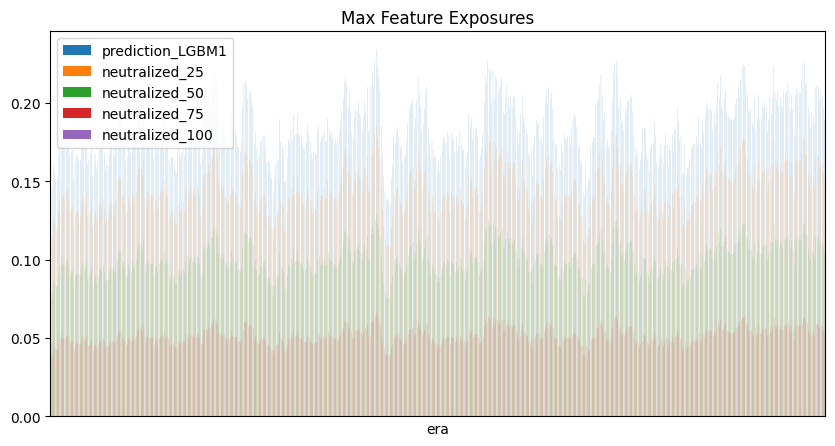

In [90]:
# Compute max feature exposure for each set of predictions
max_feature_exposures = {}
for col in prediction_LGBM1_cols:
    max_feature_exposures[col] = validation.groupby("era").apply(lambda d: d[feature_cols].corrwith(d[col]).abs().max())
max_feature_exposures = pd.DataFrame(max_feature_exposures)

# Plot max feature exposures 
max_feature_exposures.plot.bar(figsize=(10, 5), title="Max Feature Exposures", xticks=[], snap=False);

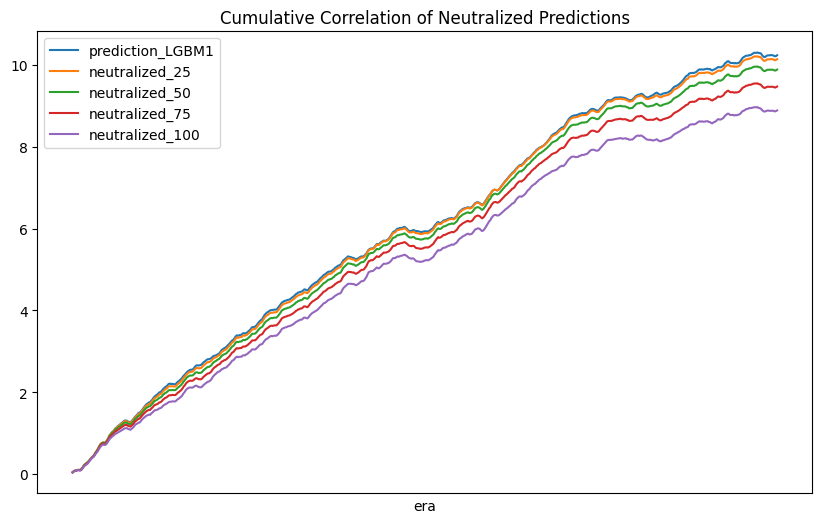

In [91]:
# Plot cumulative correlations
correlations = {}
cumulative_correlations = {}
for col in prediction_LGBM1_cols:
    correlations[col] = validation.groupby("era").apply(lambda d: practica_corr(d[col], d["target"]))
    cumulative_correlations[col] = correlations[col].cumsum() 
pd.DataFrame(cumulative_correlations).plot(title="Cumulative Correlation of Neutralized Predictions", figsize=(10, 6), xticks=[]);

In [92]:
summary_metrics = {}
for col in prediction_LGBM1_cols:
    summary_metrics[col] = compute_metrics(correlations[col], col).iloc[0]
pd.set_option('display.float_format', lambda x: '%f' % x)
summary_metrics_df = pd.DataFrame(summary_metrics).T
display(summary_metrics_df)

,mean,std,sharpe,max_drawdown
prediction_LGBM1,0.016777,0.017464,0.960704,0.127765
neutralized_25,0.016621,0.017362,0.957329,0.143623
neutralized_50,0.016204,0.017147,0.945010,0.154309
neutralized_75,0.015523,0.016881,0.919575,0.166228
neutralized_100,0.014566,0.016570,0.879062,0.176689


#### 4.2 Ridge Regression

,mean,std,sharpe,max_drawdown
Ridge Regression on Validation.parquet,0.017178,0.015946,1.077212,0.090134


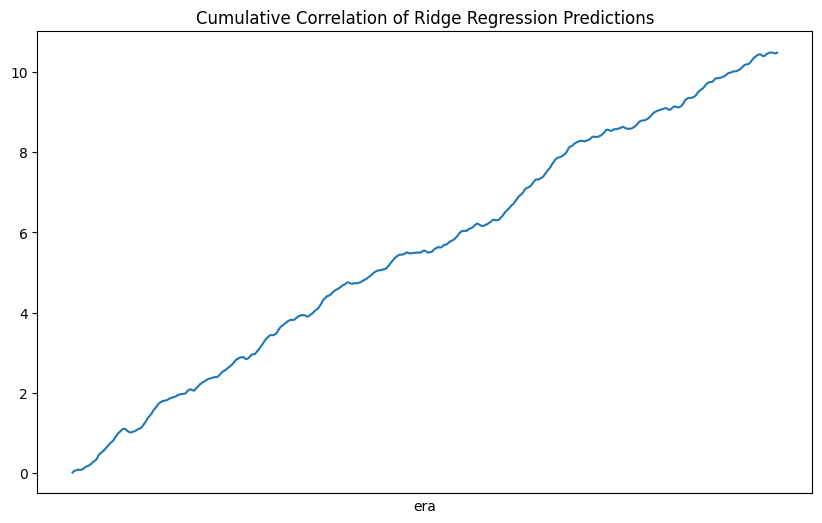

In [93]:
# Función que aplica Ridge Regression
from sklearn.linear_model import Ridge
from typing import List
def ridge_regression_features(
        df: pd.DataFrame,
        feature_cols: List[str],
        target_col: str,
        alpha: float = 1.0
):
    # Separar las características y el objetivo
    X = df[feature_cols].values
    y = df[target_col].values

    # Aplicar Ridge Regression
    model = Ridge(alpha=alpha)
    model.fit(X, y)

    df[target_col + '_ridge_pred'] = model.predict(X)
    return df

# Aplicar Ridge Regression al conjunto de validación
validation_Ridge = ridge_regression_features(
    df=validation,
    feature_cols=feature_set,
    target_col='target',
    alpha=1.0
)

# Evaluar el rendimiento de las predicciones de Ridge Regression
ridge_correlations = validation_Ridge.groupby("era").apply(lambda d: practica_corr(d['target_ridge_pred'], d["target"]))
ridge_correlations_cumsum = ridge_correlations.cumsum()
ridge_correlations_cumsum.plot(title="Cumulative Correlation of Ridge Regression Predictions", figsize=(10, 6), xticks=[]);
# Mostrar métricas resumen para Ridge Regression
metrics_ridge = compute_metrics(ridge_correlations, "Ridge Regression on Validation.parquet")
display(metrics_ridge)


#### 4.3 Resultados y conclusiones finales de las mejoras opcionales

In [94]:
all_metrics_final = pd.concat([summary_metrics_df, metrics_ridge])
display(all_metrics_final)

,mean,std,sharpe,max_drawdown
prediction_LGBM1,0.016777,0.017464,0.960704,0.127765
neutralized_25,0.016621,0.017362,0.957329,0.143623
neutralized_50,0.016204,0.017147,0.945010,0.154309
neutralized_75,0.015523,0.016881,0.919575,0.166228
neutralized_100,0.014566,0.016570,0.879062,0.176689
Ridge Regression on Validation.parquet,0.017178,0.015946,1.077212,0.090134


**Feature Neutralization** sirve para eliminar la influencia de ciertas características en las predicciones del modelo, lo que puede ayudar a mejorar la robustez y generalización del modelo. Sin embargo, en este caso particular, no ha tenido un impacto significativo en las métricas del modelo Ridge Regression. Debido a que ya de por si el modelo no estaba funcionando muy bien, la neutralización no ha aportado mejoras notables.

**Ridge Regression** es un modelo de regresión lineal que ayuda a reducir el sobreajuste mediante la penalización de los coeficientes del modelo. Es muy usado cuando hay muchas características ligeramente útiles (como en este caso), ya que ayuda a mantener todas las features en el modelo mientras controla su influencia mediante la regularización. En este caso, ha ayudado a mejorar ligeramente las métricas en comparación con el modelo LGBMRegressor original.

## 5. Submission. Evaluar con live.parquet

In [95]:
# Descargar las últimas entradas en tiempo real
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Carga dichas características
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

# Genera predicciones en vivo
live_predictions = modelLGBM1.predict(live_features[feature_set])

#Evaluar
live_predictions

# Envío
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

2025-11-04 13:53:52,439 INFO numerapi.utils: target file already exists
2025-11-04 13:53:52,440 INFO numerapi.utils: download complete


,prediction
id,
n001b5cc671480f8,0.481607
n001e484d6a60cde,0.500536
n002a862c140978e,0.500692
n0033096bae8eb9a,0.500173
n004ec27fa53f292,0.495978
...,...
nffd60ecda65f998,0.482156
nffde21be9bf1258,0.503476
nffdec906fde9863,0.485243


In [96]:
# Use the cloudpickle library to serialize your function and its dependencies
import cloudpickle
p = cloudpickle.dumps(live_predictions)
with open("live_predictions_small.pkl", "wb") as f:
    f.write(p)